In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [13]:
df=pd.read_csv('churn_data.csv')

In [14]:
df.head() #this will display the first 5 rows

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3000 non-null   int64  
 1   Age              3000 non-null   int64  
 2   Gender           3000 non-null   object 
 3   Tenure           3000 non-null   int64  
 4   MonthlyCharges   3000 non-null   float64
 5   ContractType     3000 non-null   object 
 6   InternetService  2077 non-null   object 
 7   TotalCharges     3000 non-null   float64
 8   TechSupport      3000 non-null   object 
 9   Churn            3000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 234.5+ KB


In [16]:
df.isnull().sum()


CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    923
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [17]:
df['InternetService'].value_counts()

InternetService
Fiber Optic    1176
DSL             901
Name: count, dtype: int64

In [18]:
df['InternetService']=df['InternetService'].fillna('')

In [19]:
df.isnull().sum()


CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [20]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [21]:
df.duplicated().sum()

0

In [22]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,502.898333,44.712667,18.999333,73.687380,1393.438577
std,290.711630,9.751639,18.692988,25.684526,1561.971037
min,1.000000,12.000000,0.000000,30.000000,0.000000
25%,248.750000,38.000000,5.000000,50.917500,351.200000
50%,505.500000,45.000000,13.000000,72.960000,868.160000
75%,760.000000,51.000000,26.000000,95.250000,1872.052500
max,1000.000000,83.000000,122.000000,119.960000,12416.250000


In [23]:
numerical_columns=df.select_dtypes(include=['number']) #This will select only numerical value datatypes
# numerical_columns=df.select_dtypes(exclude='object') This will also select numerical values, but it will also take in other datatypes that are NOT object hence this will not work out

In [24]:
numerical_columns

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
2995,888,41,52,90.11,461.88
2996,795,28,62,42.87,587.86
2997,677,37,42,73.61,118.47
2998,928,25,26,104.79,184.83


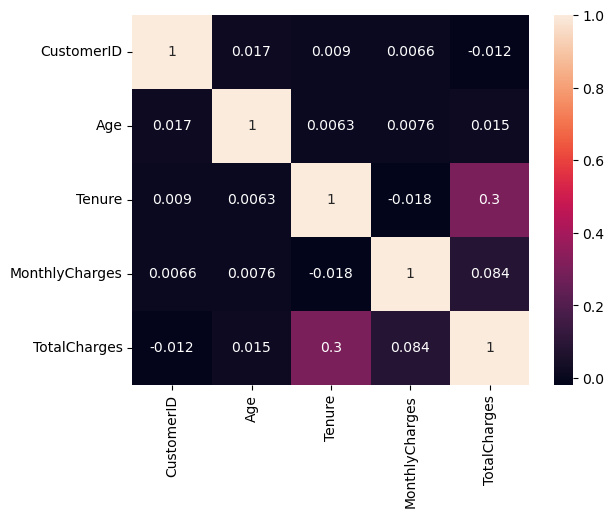

In [25]:
#This will help us see which features are highly co related and which are not hence helping us select the right features
sns.heatmap(numerical_columns.corr(),annot=True)
plt.savefig("images/Correlation.png", bbox_inches="tight")
plt.show()
plt.close()


In [26]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
2995,888,41,Male,52,90.11,Two-Year,DSL,461.88,No,Yes
2996,795,28,Female,62,42.87,Month-to-Month,DSL,587.86,No,Yes
2997,677,37,Female,42,73.61,One-Year,Fiber Optic,118.47,Yes,Yes
2998,928,25,Male,26,104.79,Month-to-Month,Fiber Optic,184.83,Yes,Yes


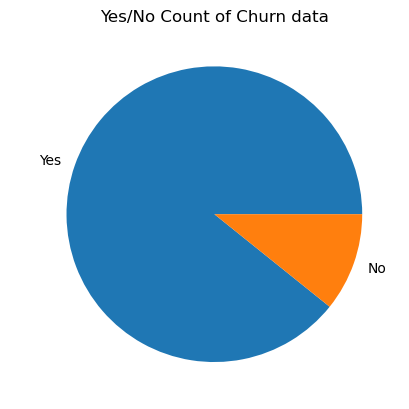

In [27]:
df['Churn'].value_counts().plot(kind='pie')   #data analysis of the churn column
plt.title("Yes/No Count of Churn data")
plt.ylabel(" ")
plt.savefig("images/Yes_No_count.png", bbox_inches="tight")
plt.show()
plt.close()
#Verdict- Majority of our customers churn out to give a YES output

### Now we will group the data by Churn that is YES OR NO and then calculate what they pay on average

In [28]:

df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     70.936006
Yes    74.019354
Name: MonthlyCharges, dtype: float64

In [29]:
df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    69.667865
       Male      72.492759
Yes    Female    73.496575
       Male      74.638075
Name: MonthlyCharges, dtype: float64

In [30]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [31]:
df.groupby("Churn")['Age'].mean()

Churn
No     43.826625
Yes    44.819574
Name: Age, dtype: float64

In [32]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    74.141593
One-Year          73.431357
Two-Year          72.923035
Name: MonthlyCharges, dtype: float64

In [33]:
df.groupby("ContractType")["MonthlyCharges"].mean().dtype

dtype('float64')

### We can see that , Longer the contract cheaper the mean monthly charges are

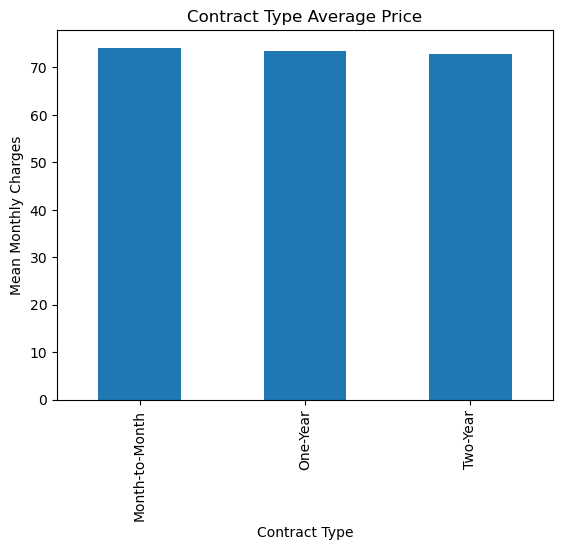

In [34]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind='bar')
plt.title("Contract Type Average Price")
plt.ylabel("Mean Monthly Charges")
plt.xlabel("Contract Type")
plt.savefig("images/Contract_type_data_counts.png", bbox_inches="tight")
plt.show()
plt.close()

In [35]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
2995,888,41,Male,52,90.11,Two-Year,DSL,461.88,No,Yes
2996,795,28,Female,62,42.87,Month-to-Month,DSL,587.86,No,Yes
2997,677,37,Female,42,73.61,One-Year,Fiber Optic,118.47,Yes,Yes
2998,928,25,Male,26,104.79,Month-to-Month,Fiber Optic,184.83,Yes,Yes


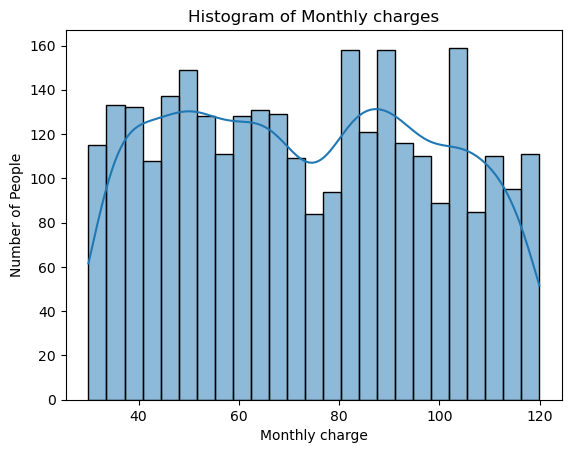

In [36]:
sns.histplot(df['MonthlyCharges'],bins=25,kde=True)
plt.title("Histogram of Monthly charges")
plt.ylabel("Number of People")
plt.xlabel("Monthly charge")
plt.savefig("images/Monthly_charges_histogram.png", bbox_inches="tight")
plt.show()
plt.close()

### -> From this we conclude that majority of people pay average or less monthly charges whereas a very small % pay high monthly charges. Churning of these high paying customers will lead to major revenue loss

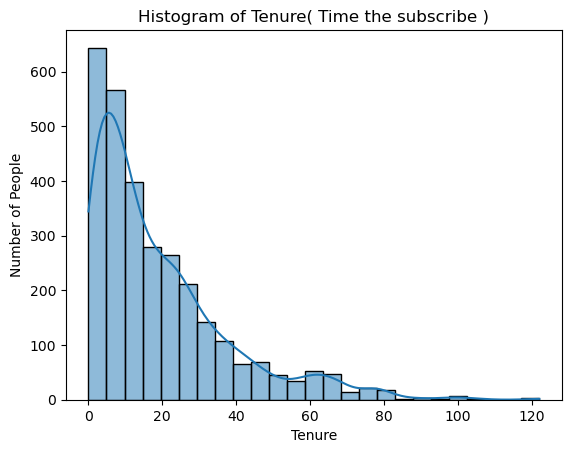

In [37]:
sns.histplot(df['Tenure'],bins=25,kde=True)
plt.title("Histogram of Tenure( Time the subscribe )")
plt.ylabel("Number of People")
plt.xlabel("Tenure")
plt.savefig("images/Tenure_histogram.png", bbox_inches="tight")
plt.show()
plt.close()

### -> We can conclude from this that many many people have a very less tenure before they churn (Leave/unsubscribe) from the service.
